In [12]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [13]:
import yfinance as yf

In [14]:
sp500 = yf.Ticker("^GSPC")

In [15]:
sp500 = sp500.history(period='max')

In [16]:
sp500 = sp500.loc["1950":]

In [17]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1950-01-03 00:00:00-05:00,16.660000,16.660000,16.660000,16.660000,1260000,0.0,0.0
1950-01-04 00:00:00-05:00,16.850000,16.850000,16.850000,16.850000,1890000,0.0,0.0
1950-01-05 00:00:00-05:00,16.930000,16.930000,16.930000,16.930000,2550000,0.0,0.0
1950-01-06 00:00:00-05:00,16.980000,16.980000,16.980000,16.980000,2010000,0.0,0.0
1950-01-09 00:00:00-05:00,17.080000,17.080000,17.080000,17.080000,2520000,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,0.0,0.0
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,0.0,0.0
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,0.0,0.0


In [18]:
sp500.index

DatetimeIndex(['1950-01-03 00:00:00-05:00', '1950-01-04 00:00:00-05:00',
               '1950-01-05 00:00:00-05:00', '1950-01-06 00:00:00-05:00',
               '1950-01-09 00:00:00-05:00', '1950-01-10 00:00:00-05:00',
               '1950-01-11 00:00:00-05:00', '1950-01-12 00:00:00-05:00',
               '1950-01-13 00:00:00-05:00', '1950-01-16 00:00:00-05:00',
               ...
               '2026-02-24 00:00:00-05:00', '2026-02-25 00:00:00-05:00',
               '2026-02-26 00:00:00-05:00', '2026-02-27 00:00:00-05:00',
               '2026-03-02 00:00:00-05:00', '2026-03-03 00:00:00-05:00',
               '2026-03-04 00:00:00-05:00', '2026-03-05 00:00:00-05:00',
               '2026-03-06 00:00:00-05:00', '2026-03-09 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=19166, freq=None)

<Axes: xlabel='Date'>

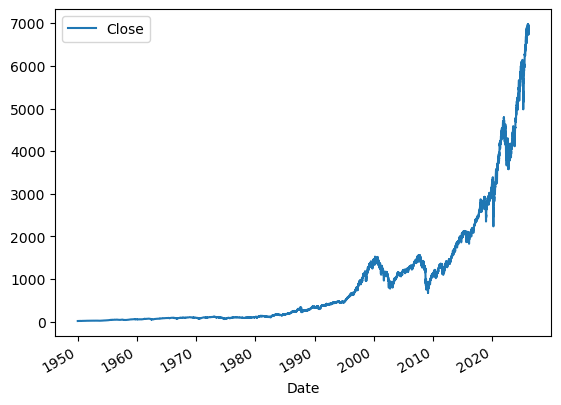

In [19]:
sp500.plot.line(y="Close", use_index=True)

In [20]:
sp500 = sp500.drop(columns=['Dividends', 'Stock Splits'])

In [21]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [22]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1950-01-03 00:00:00-05:00,16.660000,16.660000,16.660000,16.660000,1260000,16.850000
1950-01-04 00:00:00-05:00,16.850000,16.850000,16.850000,16.850000,1890000,16.930000
1950-01-05 00:00:00-05:00,16.930000,16.930000,16.930000,16.930000,2550000,16.980000
1950-01-06 00:00:00-05:00,16.980000,16.980000,16.980000,16.980000,2010000,17.080000
1950-01-09 00:00:00-05:00,17.080000,17.080000,17.080000,17.080000,2520000,17.030001
...,...,...,...,...,...,...
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,6830.709961
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,6740.020020


In [23]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [24]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1950-01-03 00:00:00-05:00,16.660000,16.660000,16.660000,16.660000,1260000,16.850000,1
1950-01-04 00:00:00-05:00,16.850000,16.850000,16.850000,16.850000,1890000,16.930000,1
1950-01-05 00:00:00-05:00,16.930000,16.930000,16.930000,16.930000,2550000,16.980000,1
1950-01-06 00:00:00-05:00,16.980000,16.980000,16.980000,16.980000,2010000,17.080000,1
1950-01-09 00:00:00-05:00,17.080000,17.080000,17.080000,17.080000,2520000,17.030001,0
...,...,...,...,...,...,...,...
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000,1
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,6830.709961,0
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,6740.020020,0


In [25]:
sp500 = sp500.loc["1990-01-01":].copy()

In [26]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000,1
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,6830.709961,0
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,6740.020020,0


In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "High", "Low"]
model.fit(train[predictors], train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])

In [30]:
import pandas as pd
preds = pd.Series(preds, index=test.index)

In [31]:
precision_score(test["Target"], preds)

0.7777777777777778

In [32]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

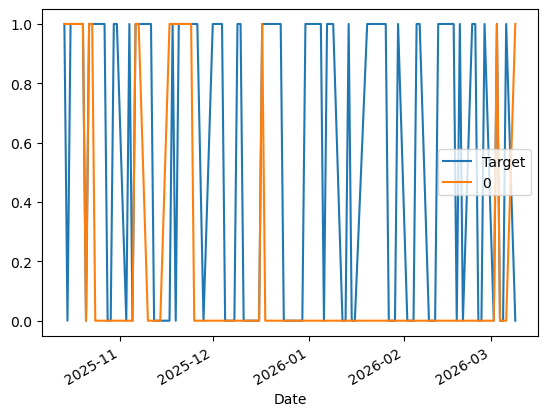

In [33]:
combined.plot()

In [34]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined
    

In [35]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)    

In [36]:
predictions = backtest(sp500, model, predictors)

In [39]:
predictions["Predictions"].value_counts()

Predictions
0    3845
1    2767
Name: count, dtype: int64

In [40]:
precision_score(predictions["Target"], predictions["Predictions"])

0.533791109504879

In [41]:
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.537356
0    0.462644
Name: count, dtype: float64

# Now adding extra predictors to improve the accuracy

In [46]:
horizons = [2,5,60,250,1000]

new_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [48]:
sp500 = sp500.dropna()

In [49]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio2,Trend_2,Close_Ratio5,Trend_5,Close_Ratio60,Trend_60,Close_Ratio250,Trend_250,Close_Ratio1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02 00:00:00-05:00,6824.359863,6901.009766,6796.850098,6881.620117,6079080000,6816.629883,0,1.000199,1.0,0.997176,3.0,0.998371,32.0,1.081684,144.0,1.347991,537.0
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000,1,0.995256,1.0,0.989865,2.0,0.989021,31.0,1.070769,144.0,1.334577,537.0
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,6830.709961,0,1.003863,1.0,0.999767,2.0,0.996662,31.0,1.078379,144.0,1.344218,538.0


In [50]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [51]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors]) [:,1]
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [52]:
predictions = backtest(sp500, model, new_predictors)

In [58]:
predictions["Predictions"].value_counts()

Predictions
0.0    4737
1.0     874
Name: count, dtype: int64

In [59]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5732265446224256

# So Now our precision score is increased but you dont have to go and trade with this model yet
# you can imporove the model with following models and then you can use this for trading on your [OWN RISK]
* This s&p 500 is from us market but you can add another market with diffrent time zone that opens up before us market and then you can get inshits about it to take a traid or not
* And also you have to ADD another model which analyze all finance news so your model have better understanding what is about to happen and what should be your 